# Paper Results Experiments

This notebook loads probe and temporal-control results directly from `artifacts/` and generates the paper tables and candidate figures described in `docs/PAPER_RESULTS_EXPERIMENTS.md`.

It is intentionally read-only with respect to `artifacts/`: all tables and plots below are computed at notebook runtime from CSV/JSON artifacts, not copied into source code.

## Loaded Artifact Sources

**Selected train/eval summary files**

,Dataset,Probe,Model,n_layers,source_path
0,IntPhys2,linear,V-JEPA,4,artifacts/probes/intphys2/intphys2_probe_linear_jepa_v1_vith16_384_20260426T152120Z/train_eval_summary.csv
1,IntPhys2,linear,V-JEPA 2,4,artifacts/probes/intphys2/intphys2_probe_linear_jepa_v2_vitg_384_20260430T105417Z/train_eval_summary.csv
2,IntPhys2,linear,V-JEPA 2.1,4,artifacts/probes/intphys2/intphys2_probe_linear_jepa_v2_1_vitG_384_20260430T105417Z/train_eval_summary.csv
3,IntPhys2,linear,LTX-Video,40,artifacts/probes/intphys2/ltx_linear_all_40_optuna/train_eval_summary.csv
4,IntPhys2,linear,VideoMAE,4,artifacts/probes/intphys2/intphys2_probe_linear_videomae_vit_huge_16_224_20260426T152120Z/train_eval_summary.csv
5,IntPhys2,linear,VideoMAE-v2,4,artifacts/probes/intphys2/intphys2_probe_linear_videomae_v2_vit_giant_16_224_20260426T152148Z/train_eval_summary.csv
6,IntPhys2,MLP,V-JEPA,4,artifacts/probes/intphys2/intphys2_probe_mlp_jepa_v1_vith16_384_20260508T164713Z/train_eval_summary.csv
7,IntPhys2,MLP,V-JEPA 2,4,artifacts/probes/intphys2/intphys2_probe_mlp_jepa_v2_vitg_384_20260508T164714Z/train_eval_summary.csv
8,IntPhys2,MLP,V-JEPA 2.1,4,artifacts/probes/intphys2/intphys2_probe_mlp_jepa_v2_1_vitG_384_20260508T164713Z/train_eval_summary.csv
9,IntPhys2,MLP,LTX-Video,40,artifacts/probes/intphys2/intphys2_probe_mlp_ltx_video_ltxv_13b_0_9_8_distilled_20260509T102816Z/train_eval_summary.csv


**Loaded temporal-control baseline coverage**

,Dataset,Baseline,Probe,n_rows,n_models,n_source_files,source_kinds
0,IntPhys2,Frame-shuffle,linear,60,6,6,per_run
1,IntPhys2,Frame-shuffle,MLP,60,6,6,per_run
2,IntPhys2,Frame-shuffle,attentive,20,5,5,per_run
3,IntPhys2,Single-frame,linear,60,6,6,per_run
4,IntPhys2,Single-frame,MLP,60,6,6,per_run
5,IntPhys2,Single-frame,attentive,20,5,5,per_run
6,MVP,Frame-shuffle,linear,60,6,8,per_run
7,MVP,Frame-shuffle,MLP,60,6,6,per_run
8,MVP,Single-frame,linear,60,6,7,per_run
9,MVP,Single-frame,MLP,60,6,6,per_run


...

,Model,Best layer on MVP,Best MVP score,Best layer on IntPhys2,Best IntPhys2 score
0,V-JEPA,32,87.26,24,45.10
1,V-JEPA 2,40,86.75,40,47.06
2,V-JEPA 2.1,38,70.78,38,39.22
3,VideoMAE,24,64.41,24,35.29
4,VideoMAE-v2,20,66.13,20,47.06
5,LTX-Video,noise_0.5_block_24,66.84,noise_0.2_block_24,47.06


**Table 2B: Depth-profile summary**

,Model,MVP depth trend,IntPhys2 depth trend,Peak location type
0,V-JEPA,late-rising,non-monotonic,late-rising / non-monotonic
1,V-JEPA 2,late-rising,intermediate peak,late-rising / intermediate peak
2,V-JEPA 2.1,intermediate peak,non-monotonic,intermediate peak / non-monotonic
3,VideoMAE,non-monotonic,intermediate peak,non-monotonic / intermediate peak
4,VideoMAE-v2,intermediate peak,intermediate peak,intermediate peak / intermediate peak


**Table 2C: LTX best-slot summary**

,Probe,Best noise level on MVP,Best block on MVP,Best MVP score,Best noise level on IntPhys2,Best block on IntPhys2,Best IntPhys2 score
0,linear,0.60,24.00,49.95,0.20,24.00,47.06
1,MLP,0.50,24.00,66.84,0.20,24.00,47.06


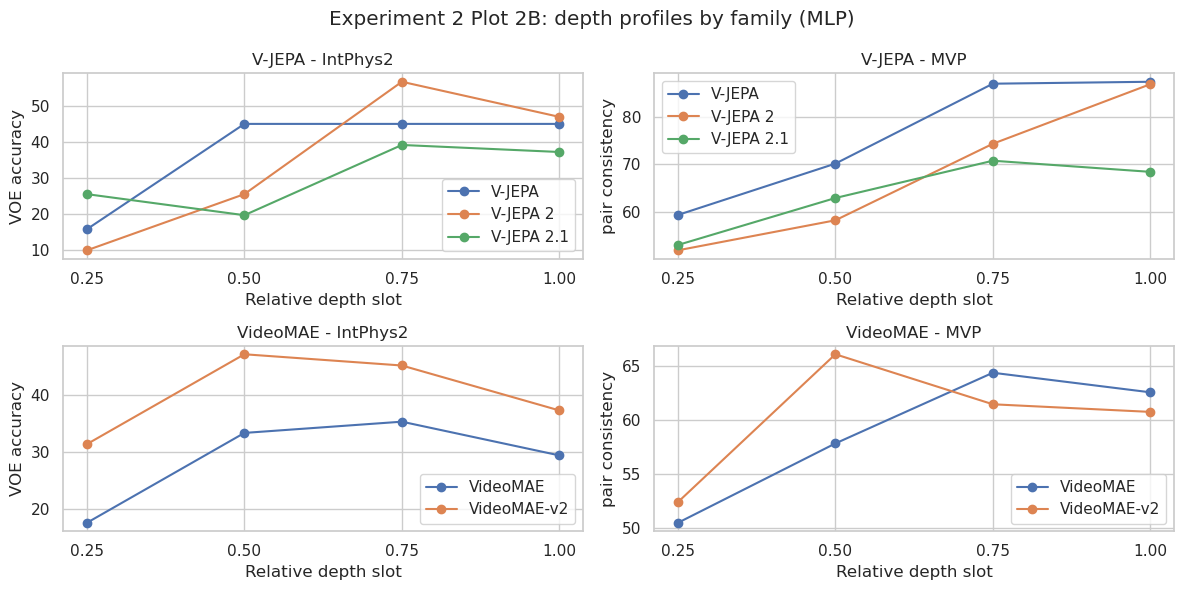

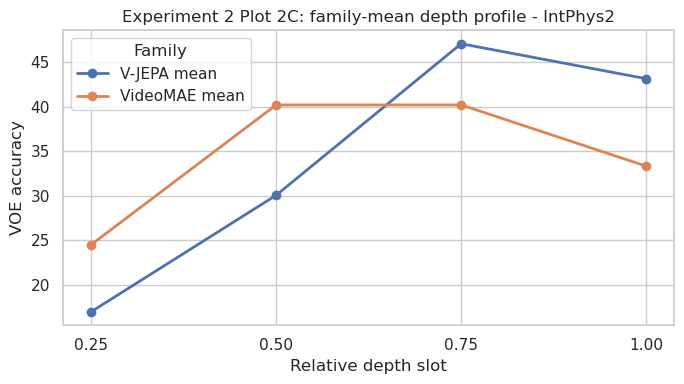

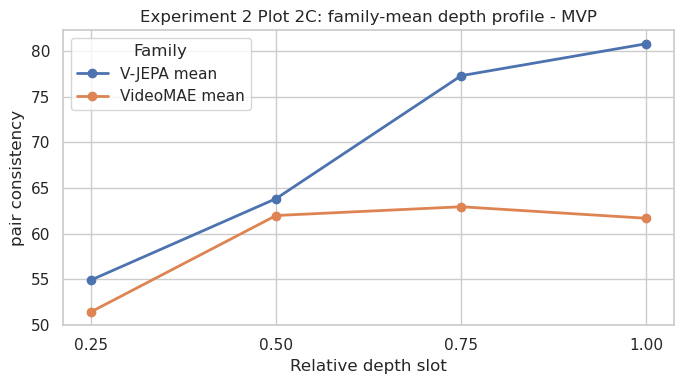

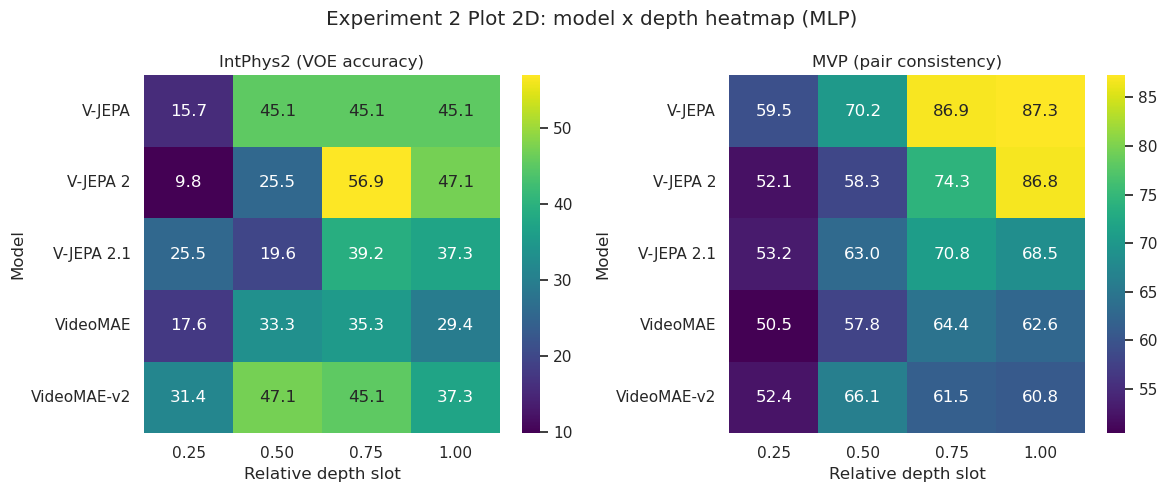

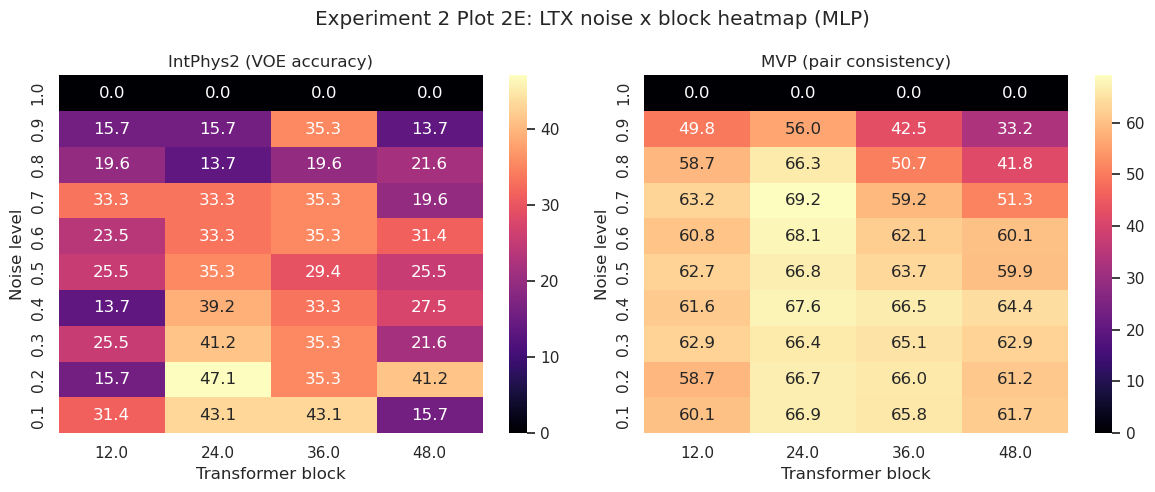

## Experiment 3: Which probe extracts the physics signal best?

**Table 3A: Best probe per model**

,Model,MVP linear score,MVP MLP score,MVP attentive score,Winning probe on MVP,IntPhys2 linear score,IntPhys2 MLP score,IntPhys2 attentive score,Winning probe on IntPhys2
0,V-JEPA,48.74,87.26,94.03,attentive,50.98,45.10,56.86,attentive
1,V-JEPA 2,47.32,86.75,92.82,attentive,41.18,47.06,58.82,attentive
2,V-JEPA 2.1,43.88,70.78,93.73,attentive,23.53,39.22,45.10,attentive
3,VideoMAE,37.51,64.41,,MLP,35.29,35.29,58.82,attentive
4,VideoMAE-v2,38.62,66.13,,MLP,37.25,47.06,9.80,MLP
5,LTX-Video,49.95,66.84,,MLP,47.06,47.06,,linear


**Table 3B: Gain over linear**

,Model,MVP MLP - linear,MVP attentive - linear,IntPhys2 MLP - linear,IntPhys2 attentive - linear
0,V-JEPA,38.52,45.30,-5.88,5.88
1,V-JEPA 2,39.43,45.50,5.88,17.65
2,V-JEPA 2.1,26.90,49.85,15.69,21.57
3,VideoMAE,26.90,,0.00,23.53
4,VideoMAE-v2,27.50,,9.80,-27.45
5,LTX-Video,16.89,,0.00,


**Table 3C: Probe winner counts**

,Dataset,Probe,Number of wins,Average margin over second-best
0,MVP,linear,0,
1,MVP,MLP,3,23.76
2,MVP,attentive,3,11.93
3,IntPhys2,linear,1,0.00
4,IntPhys2,MLP,1,9.80
5,IntPhys2,attentive,4,11.76


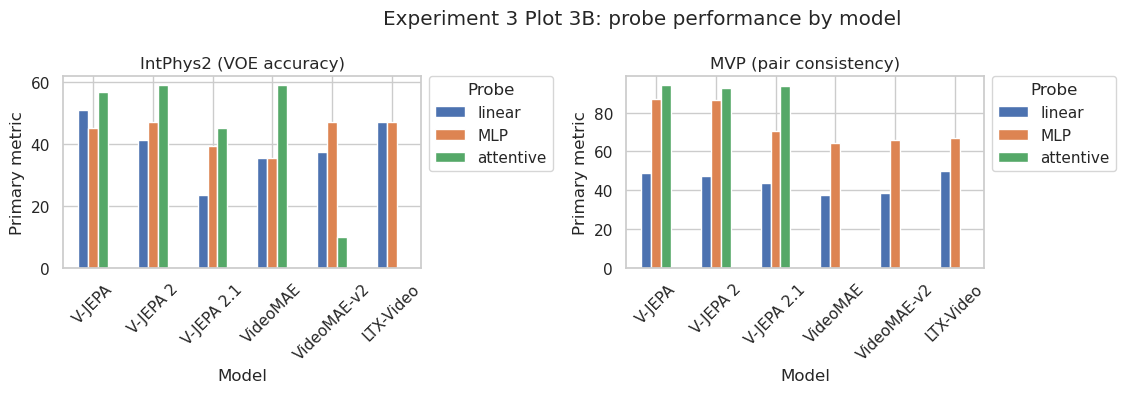

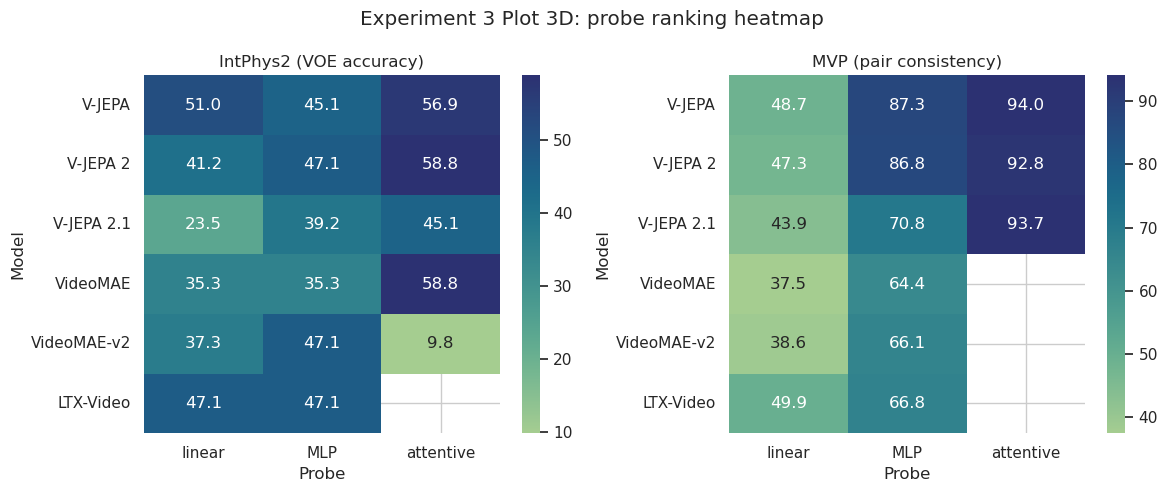

## Experiment 4: What happens under temporal control experiments?

**Table 4A: Main control table**

baseline_key,Dataset,Model,Best layer,Main task score,Frame-shuffle score,Single-frame score,Drop under frame-shuffle,Drop under single-frame
0,IntPhys2,V-JEPA,24,45.10,25.49,7.84,19.61,37.25
1,IntPhys2,V-JEPA 2,40,47.06,25.49,19.61,21.57,27.45
2,IntPhys2,V-JEPA 2.1,38,39.22,29.41,19.61,9.80,19.61
3,IntPhys2,VideoMAE,24,35.29,13.73,13.73,21.57,21.57
4,IntPhys2,VideoMAE-v2,20,47.06,13.73,11.76,33.33,35.29
5,IntPhys2,LTX-Video,noise_0.2_block_24,47.06,15.69,21.57,31.37,25.49
6,MVP,V-JEPA,32,87.26,38.93,0.00,48.33,87.26
7,MVP,V-JEPA 2,40,86.75,40.44,5.76,46.31,80.99
8,MVP,V-JEPA 2.1,38,70.78,36.00,4.95,34.78,65.82
9,MVP,VideoMAE,24,64.41,39.13,4.45,25.28,59.96


**Table 4B: Retention table**

baseline_key,Dataset,Model,Main task,Shuffle retention (%),Single-frame retention (%)
0,IntPhys2,V-JEPA,45.10,56.52,17.39
1,IntPhys2,V-JEPA 2,47.06,54.17,41.67
2,IntPhys2,V-JEPA 2.1,39.22,75.00,50.00
3,IntPhys2,VideoMAE,35.29,38.89,38.89
4,IntPhys2,VideoMAE-v2,47.06,29.17,25.00
5,IntPhys2,LTX-Video,47.06,33.33,45.83
6,MVP,V-JEPA,87.26,44.61,0.00
7,MVP,V-JEPA 2,86.75,46.62,6.64
8,MVP,V-JEPA 2.1,70.78,50.86,7.00
9,MVP,VideoMAE,64.41,60.75,6.91


**Table 4C: Semantic-control appendix table**

,Dataset,Model,Control,Best layer,Original-label score,all_true score,all_false score
0,IntPhys2,V-JEPA,Frame-shuffle,24,25.49,0.00,0.00
1,IntPhys2,V-JEPA 2,Frame-shuffle,40,25.49,0.00,0.00
2,IntPhys2,V-JEPA 2.1,Frame-shuffle,38,29.41,0.00,0.00
3,IntPhys2,LTX-Video,Frame-shuffle,noise_0.2_block_24,15.69,0.00,0.00
4,IntPhys2,VideoMAE,Frame-shuffle,24,13.73,0.00,0.00
5,IntPhys2,VideoMAE-v2,Frame-shuffle,20,13.73,0.00,0.00
6,IntPhys2,V-JEPA,Single-frame,24,7.84,0.00,0.00
7,IntPhys2,V-JEPA 2,Single-frame,40,19.61,0.00,0.00
8,IntPhys2,V-JEPA 2.1,Single-frame,38,19.61,0.00,0.00
9,IntPhys2,LTX-Video,Single-frame,noise_0.2_block_24,21.57,0.00,0.00


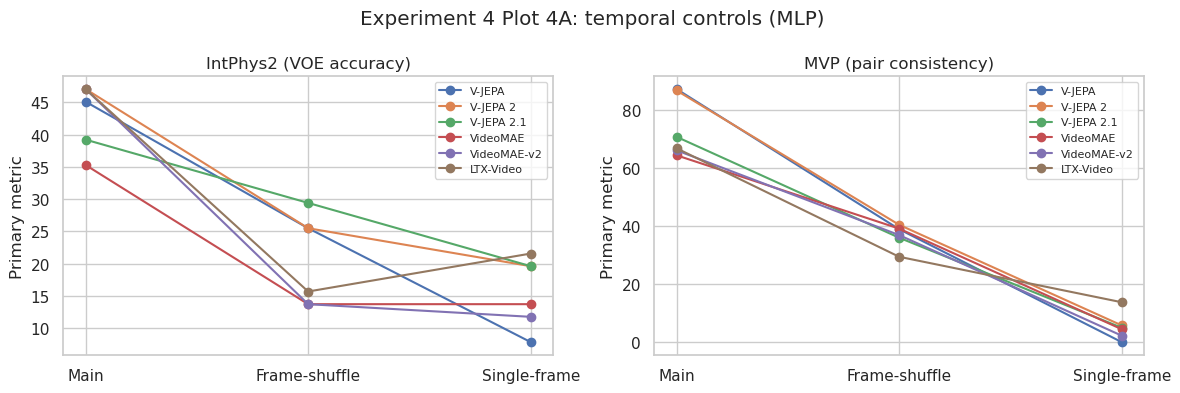

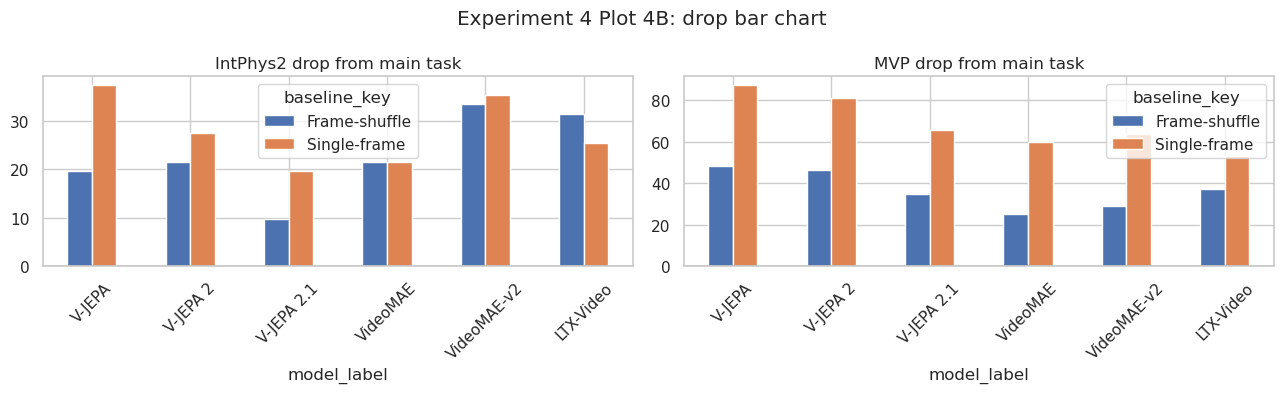

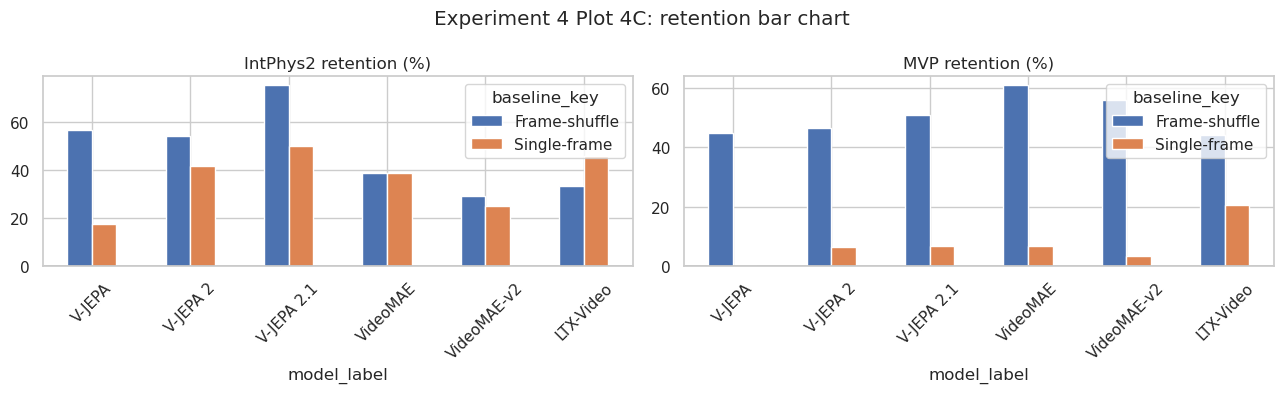

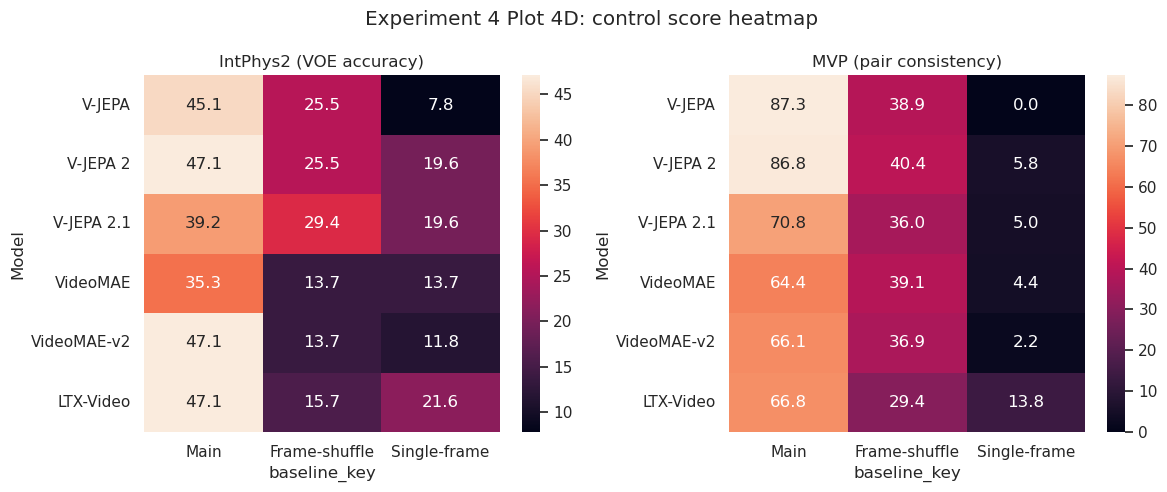

In [2]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('This notebook requires matplotlib for the requested plots. Update the conda environment from environment.yml or install matplotlib in the active notebook kernel.') from exc
from IPython.display import Markdown, display

try:
    import seaborn as sns
except Exception:
    sns = None

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

if sns is not None:
    sns.set_theme(style='whitegrid', context='notebook')
else:
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.25})

REPO_ROOT = Path.cwd()
ARTIFACTS = REPO_ROOT / 'artifacts'

HEADLINE_PROBE = 'mlp'
CONTROL_PROBE = HEADLINE_PROBE
PROBE_ORDER = ['linear', 'mlp', 'temporal_attn']
PROBE_LABEL = {'linear': 'linear', 'mlp': 'MLP', 'temporal_attn': 'attentive'}

DATASET_ORDER = ['mvp', 'intphys2']
PANEL_DATASET_ORDER = ['intphys2', 'mvp']
DATASET_LABEL = {'mvp': 'MVP', 'intphys2': 'IntPhys2'}
PRIMARY_METRIC = {'mvp': 'pair_consistency', 'intphys2': 'voe_accuracy'}
PRIMARY_LABEL = {'mvp': 'pair consistency', 'intphys2': 'VOE accuracy'}

MODEL_ORDER = ['jepa_v1', 'jepa_v2', 'jepa_v2_1', 'videomae', 'videomae_v2', 'ltx_video']
MODEL_ORDER_INDEX = {key: idx for idx, key in enumerate(MODEL_ORDER)}
MODEL_META = {
    'jepa_v1': {'label': 'V-JEPA', 'family': 'V-JEPA', 'objective': 'self-supervised predictive video representation'},
    'jepa_v2': {'label': 'V-JEPA 2', 'family': 'V-JEPA', 'objective': 'self-supervised predictive video representation'},
    'jepa_v2_1': {'label': 'V-JEPA 2.1', 'family': 'V-JEPA', 'objective': 'self-supervised predictive video representation'},
    'videomae': {'label': 'VideoMAE', 'family': 'VideoMAE', 'objective': 'masked video autoencoding'},
    'videomae_v2': {'label': 'VideoMAE-v2', 'family': 'VideoMAE', 'objective': 'masked video autoencoding'},
    'ltx_video': {'label': 'LTX-Video', 'family': 'Diffusion video model', 'objective': 'video diffusion generation'},
}
CONTROL_LABEL = {'frame_shuffle': 'Frame-shuffle', 'single_frame': 'Single-frame'}

if not ARTIFACTS.exists():
    raise FileNotFoundError(f'Expected artifacts directory at {ARTIFACTS}')

def relpath(path):
    path = Path(path)
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)

def canonical_dataset(text):
    low = str(text).lower()
    if 'intphys2' in low:
        return 'intphys2'
    if 'mvp' in low:
        return 'mvp'
    return None

def canonical_model(text):
    low = str(text).lower()
    if 'jepa_v2_1' in low or 'vjepa2_1' in low:
        return 'jepa_v2_1'
    if 'jepa_v2' in low or 'vjepa2' in low:
        return 'jepa_v2'
    if 'jepa_v1' in low or 'vjepa1' in low:
        return 'jepa_v1'
    if 'videomae_v2' in low or 'videomaev2' in low:
        return 'videomae_v2'
    if 'videomae' in low:
        return 'videomae'
    if 'ltx_video' in low or 'ltxv' in low or 'ltx_' in low:
        return 'ltx_video'
    return None

def canonical_probe(text):
    low = str(text).lower()
    if 'temporal_attn' in low or 'attentive' in low:
        return 'temporal_attn'
    if low == 'mlp':
        return 'mlp'
    if low == 'linear':
        return 'linear'
    if '_mlp_' in low or 'probe_mlp' in low or low.endswith('_mlp'):
        return 'mlp'
    if '_linear_' in low or 'probe_linear' in low or 'ltx_linear' in low or low.endswith('_linear'):
        return 'linear'
    return None

def parse_ltx_slot(label):
    if label is None or pd.isna(label):
        return (np.nan, np.nan)
    match = re.search(r'noise_([0-9.]+)_block_(\d+)', str(label))
    if not match:
        return (np.nan, np.nan)
    return (float(match.group(1)), int(match.group(2)))

def source_metadata(path):
    path = Path(path)
    parts_lower = [part.lower() for part in path.parts]
    root_name = path.parent.name
    dataset = None
    if 'probes' in parts_lower:
        idx = parts_lower.index('probes')
        if idx + 1 < len(path.parts):
            dataset = canonical_dataset(path.parts[idx + 1])
    elif 'derived_probe_roots' in parts_lower:
        dataset = canonical_dataset(root_name)
    text = ' '.join([str(path), root_name])
    return {
        'dataset': dataset,
        'probe': canonical_probe(text),
        'model_key': canonical_model(text),
        'source_root': root_name,
        'is_partial_summary': path.name.endswith('.partial.csv'),
    }

def source_rank(path, n_rows):
    text = str(path).lower()
    rank = float(n_rows)
    if 'derived_probe_roots' in text:
        rank += 1200
    if 'complete_40' in text or 'ltx_linear_all_40_optuna' in text:
        rank += 1000
    if 'lr_matrix' in text:
        rank += 500
    if 'retry_missing' in text or 'retry' in text:
        rank += 150
    if 'old_' in text or '/old' in text:
        rank -= 1000
    if text.endswith('.partial.csv'):
        rank -= 100
    return rank

def coerce_numeric_columns(df):
    skip = {'layer_label', 'objective_metric_name', 'selection_metric_name', 'selected_lr_tag', 'checkpoint'}
    for col in df.columns:
        if col in skip or col.endswith('_path') or col.endswith('path'):
            continue
        if col == 'layer' or col.startswith(('train_', 'val_', 'test_', 'objective_', 'selection_', 'selected_lr')):
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def add_primary_columns(df):
    df = df.copy()
    df['primary_metric'] = df['dataset'].map(PRIMARY_METRIC)
    df['val_primary'] = np.nan
    df['test_primary'] = np.nan
    df['test_accuracy_metric'] = np.nan
    df['test_auc_metric'] = np.nan
    for dataset, metric in PRIMARY_METRIC.items():
        mask = df['dataset'].eq(dataset)
        val_col = f'val_{metric}'
        test_col = f'test_{metric}'
        if val_col in df.columns:
            df.loc[mask, 'val_primary'] = pd.to_numeric(df.loc[mask, val_col], errors='coerce')
        if test_col in df.columns:
            df.loc[mask, 'test_primary'] = pd.to_numeric(df.loc[mask, test_col], errors='coerce')
        if 'test_accuracy' in df.columns:
            df.loc[mask, 'test_accuracy_metric'] = pd.to_numeric(df.loc[mask, 'test_accuracy'], errors='coerce')
        for auc_col in ('test_roc_auc', 'test_auc'):
            if auc_col in df.columns:
                df.loc[mask, 'test_auc_metric'] = pd.to_numeric(df.loc[mask, auc_col], errors='coerce')
                break
    df['model_label'] = df['model_key'].map(lambda key: MODEL_META.get(key, {}).get('label', key))
    df['family'] = df['model_key'].map(lambda key: MODEL_META.get(key, {}).get('family', key))
    df['pretraining_objective'] = df['model_key'].map(lambda key: MODEL_META.get(key, {}).get('objective', ''))
    df['model_order'] = df['model_key'].map(MODEL_ORDER_INDEX).fillna(999).astype(int)
    return df

def add_depth_columns(df):
    df = df.copy()
    slots = df['layer_label'].map(parse_ltx_slot)
    df['ltx_noise_level'] = [slot[0] for slot in slots]
    df['ltx_block'] = [slot[1] for slot in slots]
    df['is_ltx'] = df['model_key'].eq('ltx_video')
    df['relative_depth'] = np.nan
    df['relative_depth_label'] = pd.NA
    non_ltx = df[~df['is_ltx']].copy()
    if not non_ltx.empty:
        non_ltx['layer_num'] = pd.to_numeric(non_ltx['layer'], errors='coerce')
        non_ltx = non_ltx.sort_values(['dataset', 'probe', 'model_key', 'layer_num'])
        groups = non_ltx.groupby(['dataset', 'probe', 'model_key'], sort=False)
        counts = groups['layer_num'].transform('count')
        ranks = groups.cumcount() + 1
        rel = ranks / counts
        df.loc[non_ltx.index, 'relative_depth'] = rel.to_numpy()
        df.loc[non_ltx.index, 'relative_depth_label'] = [f'{value:.2f}' for value in rel]
    return df

def read_summary_file(path):
    path = Path(path)
    meta = source_metadata(path)
    if not meta['dataset'] or not meta['probe'] or not meta['model_key']:
        return None, None
    df = pd.read_csv(path, dtype={'layer_label': 'string'})
    if df.empty:
        return None, None
    if 'layer_label' not in df.columns and 'layer' in df.columns:
        df['layer_label'] = df['layer'].astype('Int64').astype('string')
    df['layer_label'] = df['layer_label'].astype('string')
    df = coerce_numeric_columns(df)
    source_path = relpath(path)
    rank = source_rank(path, len(df))
    try:
        mtime = path.stat().st_mtime
    except OSError:
        mtime = np.nan
    for key, value in meta.items():
        df[key] = value
    df['source_path'] = source_path
    df['source_rank'] = rank
    df['source_mtime'] = mtime
    record = {
        **meta,
        'source_path': source_path,
        'source_rank': rank,
        'source_mtime': mtime,
        'n_layers': len(df),
    }
    return df, record

def discover_probe_summary_paths():
    patterns = [
        'probes/*/*/train_eval_summary.csv',
        'probes/*/*/train_eval_summary.partial.csv',
        'probes/*/*/*/train_eval_summary.csv',
        'probes/*/*/*/train_eval_summary.partial.csv',
        'derived_probe_roots/*/train_eval_summary.csv',
        'derived_probe_roots/*/train_eval_summary.partial.csv',
    ]
    paths = []
    for pattern in patterns:
        paths.extend(ARTIFACTS.glob(pattern))
    return sorted(set(paths))

def load_probe_results():
    frames = []
    records = []
    for path in discover_probe_summary_paths():
        frame, record = read_summary_file(path)
        if frame is None:
            continue
        frames.append(frame)
        records.append(record)
    if not frames:
        raise FileNotFoundError('No train_eval_summary CSV files were found under artifacts/probes or artifacts/derived_probe_roots')
    source_catalog = pd.DataFrame(records)
    selected_sources = (
        source_catalog.sort_values(['dataset', 'probe', 'model_key', 'source_rank', 'source_mtime'])
        .drop_duplicates(['dataset', 'probe', 'model_key'], keep='last')
        .sort_values(['dataset', 'probe', 'model_key'])
        .reset_index(drop=True)
    )
    selected_paths = set(selected_sources['source_path'])
    all_rows = pd.concat(frames, ignore_index=True, sort=False)
    results = all_rows[all_rows['source_path'].isin(selected_paths)].copy()
    results = add_primary_columns(results)
    results = add_depth_columns(results)
    return results, source_catalog, selected_sources

def select_best_layers(results):
    candidates = results.dropna(subset=['val_primary']).copy()
    ordered = candidates.sort_values(['dataset', 'probe', 'model_key', 'val_primary', 'test_primary', 'source_rank'])
    best = ordered.groupby(['dataset', 'probe', 'model_key'], group_keys=False).tail(1).copy()
    best['primary_score'] = best['test_primary']
    best['best_validation_score'] = best['val_primary']
    best['test_accuracy_score'] = best['test_accuracy_metric']
    best['test_auc_score'] = best['test_auc_metric']
    best = best.sort_values(['dataset', 'probe', 'model_order']).reset_index(drop=True)
    return best

def discover_control_metric_paths():
    patterns = [
        'results/*/baseline_label_metrics_all.csv',
        'results/*/*/baseline_label_metrics.csv',
    ]
    paths = []
    for pattern in patterns:
        paths.extend(ARTIFACTS.glob(pattern))
    return sorted(set(paths))

def load_controls():
    paths = discover_control_metric_paths()
    frames = []
    for path in paths:
        df = pd.read_csv(path, dtype={'layer_label': 'string', 'run_id': 'string'})
        if df.empty:
            continue
        df['result_path'] = relpath(path)
        df['source_kind'] = 'aggregate' if path.name == 'baseline_label_metrics_all.csv' else 'per_run'
        df['source_priority'] = 0 if path.name == 'baseline_label_metrics_all.csv' else 1
        df['dataset'] = canonical_dataset(path.parent.name)
        if 'layer_label' not in df.columns and 'layer' in df.columns:
            df['layer_label'] = df['layer'].astype('Int64').astype('string')
        df['layer_label'] = df['layer_label'].astype('string')
        probe_text = df.get('probe', pd.Series('', index=df.index)).astype(str)
        df['probe'] = probe_text.map(canonical_probe)
        model_text = (
            df.get('backbone', pd.Series('', index=df.index)).fillna('').astype(str)
            + ' '
            + df.get('summary_path', pd.Series('', index=df.index)).fillna('').astype(str)
        )
        df['model_key'] = model_text.map(canonical_model)
        for col in df.columns:
            if col in {'dataset', 'baseline', 'backbone', 'backbone_variant', 'probe', 'run_id', 'layer_label', 'prediction_file', 'summary_path', 'result_path', 'model_key'}:
                continue
            if col == 'layer' or col.endswith('_accuracy') or col.endswith('_pair_consistency') or col.endswith('_voe_accuracy') or col.endswith('_roc_auc'):
                df[col] = pd.to_numeric(df[col], errors='coerce')
        df['run_id_num'] = pd.to_numeric(df['run_id'], errors='coerce')
        frames.append(df)
    if not frames:
        return pd.DataFrame()
    controls = pd.concat(frames, ignore_index=True, sort=False)
    controls = controls.dropna(subset=['dataset', 'probe', 'model_key', 'baseline', 'layer_label'])
    controls['baseline_key'] = controls['baseline'].replace({'displacement': 'frame_shuffle', 'single_frame': 'single_frame'})
    controls['control_label'] = controls['baseline_key'].map(CONTROL_LABEL).fillna(controls['baseline_key'])
    controls['original_primary'] = np.nan
    controls['all_true_primary'] = np.nan
    controls['all_false_primary'] = np.nan
    for dataset, metric in PRIMARY_METRIC.items():
        mask = controls['dataset'].eq(dataset)
        for prefix, out_col in [('original', 'original_primary'), ('all_true', 'all_true_primary'), ('all_false', 'all_false_primary')]:
            col = f'{prefix}_{metric}'
            if col in controls.columns:
                controls.loc[mask, out_col] = pd.to_numeric(controls.loc[mask, col], errors='coerce')
    controls['model_label'] = controls['model_key'].map(lambda key: MODEL_META.get(key, {}).get('label', key))
    controls['model_order'] = controls['model_key'].map(MODEL_ORDER_INDEX).fillna(999).astype(int)
    controls = (
        controls.sort_values(['dataset', 'baseline_key', 'model_key', 'probe', 'layer_label', 'run_id_num', 'source_priority', 'result_path'])
        .drop_duplicates(['dataset', 'baseline_key', 'model_key', 'probe', 'layer_label'], keep='last')
        .reset_index(drop=True)
    )
    return controls

def control_source_summary(controls):
    if controls.empty:
        return pd.DataFrame()
    summary = (
        controls.groupby(['dataset', 'baseline_key', 'probe'], as_index=False)
        .agg(
            n_rows=('result_path', 'size'),
            n_models=('model_key', 'nunique'),
            n_source_files=('result_path', 'nunique'),
            source_kinds=('source_kind', lambda values: ', '.join(sorted(pd.Series(values).dropna().unique()))),
        )
        .sort_values(['dataset', 'baseline_key', 'probe'])
    )
    summary['Dataset'] = summary['dataset'].map(DATASET_LABEL)
    summary['Baseline'] = summary['baseline_key'].map(CONTROL_LABEL).fillna(summary['baseline_key'])
    summary['Probe'] = summary['probe'].map(PROBE_LABEL).fillna(summary['probe'])
    return summary[['Dataset', 'Baseline', 'Probe', 'n_rows', 'n_models', 'n_source_files', 'source_kinds']]

def show_table(df, title):
    display(Markdown(f'**{title}**'))
    display(df.style.format(precision=2, na_rep=''))

def model_row_order(df):
    return df.assign(_order=df['model_key'].map(MODEL_ORDER_INDEX).fillna(999)).sort_values('_order').drop(columns='_order')

def row_for(df, dataset, model_key, probe=None):
    mask = df['dataset'].eq(dataset) & df['model_key'].eq(model_key)
    if probe is not None:
        mask &= df['probe'].eq(probe)
    rows = df[mask]
    if rows.empty:
        return None
    return rows.iloc[0]

def value_or_nan(row, column):
    if row is None or column not in row:
        return np.nan
    return row[column]

def layer_or_blank(row):
    if row is None:
        return pd.NA
    return row.get('layer_label', pd.NA)

def table_1a(best, probe=HEADLINE_PROBE):
    rows = []
    for model_key in MODEL_ORDER:
        meta = MODEL_META[model_key]
        mvp = row_for(best, 'mvp', model_key, probe)
        intphys = row_for(best, 'intphys2', model_key, probe)
        rows.append({
            'Model family': meta['label'],
            'Pretraining objective': meta['objective'],
            'Best MVP layer': layer_or_blank(mvp),
            'MVP pair consistency': value_or_nan(mvp, 'primary_score'),
            'MVP accuracy': value_or_nan(mvp, 'test_accuracy_score'),
            'Best IntPhys2 layer': layer_or_blank(intphys),
            'IntPhys2 VOE': value_or_nan(intphys, 'primary_score'),
            'IntPhys2 accuracy': value_or_nan(intphys, 'test_accuracy_score'),
        })
    return pd.DataFrame(rows)

def table_1b(best, probe=HEADLINE_PROBE):
    rows = []
    for model_key in MODEL_ORDER:
        mvp = row_for(best, 'mvp', model_key, probe)
        intphys = row_for(best, 'intphys2', model_key, probe)
        rows.append({
            'model_key': model_key,
            'Model': MODEL_META[model_key]['label'],
            'MVP primary metric': value_or_nan(mvp, 'primary_score'),
            'IntPhys2 primary metric': value_or_nan(intphys, 'primary_score'),
        })
    df = pd.DataFrame(rows)
    df['MVP rank'] = df['MVP primary metric'].rank(ascending=False, method='min')
    df['IntPhys2 rank'] = df['IntPhys2 primary metric'].rank(ascending=False, method='min')
    return df.drop(columns='model_key')

def table_1_dataset_compact(best, dataset, probe=HEADLINE_PROBE):
    rows = []
    metric_col = f'{DATASET_LABEL[dataset]} {PRIMARY_LABEL[dataset]}'
    auc_col = f'{DATASET_LABEL[dataset]} AUC'
    for model_key in MODEL_ORDER:
        row = row_for(best, dataset, model_key, probe)
        rows.append({
            'Model': MODEL_META[model_key]['label'],
            'Best layer': layer_or_blank(row),
            metric_col: value_or_nan(row, 'primary_score'),
            auc_col: value_or_nan(row, 'test_auc_score'),
        })
    return pd.DataFrame(rows)

def table_1c(best, probe=HEADLINE_PROBE):
    sub = best[best['probe'].eq(probe)].copy()
    rows = []
    for family, family_df in sub.groupby('family'):
        mvp = family_df[family_df['dataset'].eq('mvp')].sort_values('primary_score').tail(1)
        intphys = family_df[family_df['dataset'].eq('intphys2')].sort_values('primary_score').tail(1)
        rep = ', '.join(sorted(family_df['model_label'].dropna().unique()))
        rows.append({
            'Family': family,
            'Representative model(s)': rep,
            'Best result on MVP': pd.NA if mvp.empty else f"{mvp.iloc[0]['model_label']} @ {mvp.iloc[0]['layer_label']} ({mvp.iloc[0]['primary_score']:.2f})",
            'Best result on IntPhys2': pd.NA if intphys.empty else f"{intphys.iloc[0]['model_label']} @ {intphys.iloc[0]['layer_label']} ({intphys.iloc[0]['primary_score']:.2f})",
            'Narrative takeaway': 'computed from loaded best-layer rows',
        })
    return pd.DataFrame(rows)

def table_2a(results, probe=HEADLINE_PROBE):
    best = select_best_layers(results[results['probe'].eq(probe)])
    rows = []
    for model_key in MODEL_ORDER:
        mvp = row_for(best, 'mvp', model_key)
        intphys = row_for(best, 'intphys2', model_key)
        rows.append({
            'Model': MODEL_META[model_key]['label'],
            'Best layer on MVP': layer_or_blank(mvp),
            'Best MVP score': value_or_nan(mvp, 'primary_score'),
            'Best layer on IntPhys2': layer_or_blank(intphys),
            'Best IntPhys2 score': value_or_nan(intphys, 'primary_score'),
        })
    return pd.DataFrame(rows)

def classify_trend(values, tolerance=2.0):
    y = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(y) < 3:
        return 'insufficient'
    if np.nanmax(y) - np.nanmin(y) <= tolerance:
        return 'flat'
    peak_idx = int(np.nanargmax(y))
    if peak_idx == len(y) - 1 and np.all(np.diff(y) >= -tolerance):
        return 'late-rising'
    if 0 < peak_idx < len(y) - 1 and y[peak_idx] - y[-1] > tolerance:
        return 'intermediate peak'
    return 'non-monotonic'

def table_2b(results, probe=HEADLINE_PROBE):
    rows = []
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].copy()
    for model_key in [key for key in MODEL_ORDER if key != 'ltx_video']:
        row = {'Model': MODEL_META[model_key]['label']}
        labels = []
        for dataset in DATASET_ORDER:
            series = sub[(sub['dataset'].eq(dataset)) & (sub['model_key'].eq(model_key))].sort_values('relative_depth')['test_primary']
            trend = classify_trend(series)
            row[f'{DATASET_LABEL[dataset]} depth trend'] = trend
            labels.append(trend)
        row['Peak location type'] = ' / '.join(labels)
        rows.append(row)
    return pd.DataFrame(rows)

def table_2c(results):
    rows = []
    sub = results[results['model_key'].eq('ltx_video')].dropna(subset=['val_primary']).copy()
    for probe in PROBE_ORDER:
        probe_rows = sub[sub['probe'].eq(probe)]
        if probe_rows.empty:
            continue
        mvp = row_for(select_best_layers(probe_rows), 'mvp', 'ltx_video', probe)
        intphys = row_for(select_best_layers(probe_rows), 'intphys2', 'ltx_video', probe)
        rows.append({
            'Probe': PROBE_LABEL.get(probe, probe),
            'Best noise level on MVP': value_or_nan(mvp, 'ltx_noise_level'),
            'Best block on MVP': value_or_nan(mvp, 'ltx_block'),
            'Best MVP score': value_or_nan(mvp, 'primary_score'),
            'Best noise level on IntPhys2': value_or_nan(intphys, 'ltx_noise_level'),
            'Best block on IntPhys2': value_or_nan(intphys, 'ltx_block'),
            'Best IntPhys2 score': value_or_nan(intphys, 'primary_score'),
        })
    return pd.DataFrame(rows)

def table_3a(best):
    rows = []
    for model_key in MODEL_ORDER:
        row = {'Model': MODEL_META[model_key]['label']}
        for dataset in DATASET_ORDER:
            scores = {}
            for probe in PROBE_ORDER:
                scores[probe] = value_or_nan(row_for(best, dataset, model_key, probe), 'primary_score')
                row[f'{DATASET_LABEL[dataset]} {PROBE_LABEL[probe]} score'] = scores[probe]
            valid_scores = {probe: score for probe, score in scores.items() if pd.notna(score)}
            row[f'Winning probe on {DATASET_LABEL[dataset]}'] = PROBE_LABEL[max(valid_scores, key=valid_scores.get)] if valid_scores else pd.NA
        rows.append(row)
    return pd.DataFrame(rows)

def table_3b(best):
    rows = []
    for model_key in MODEL_ORDER:
        row = {'Model': MODEL_META[model_key]['label']}
        for dataset in DATASET_ORDER:
            linear = value_or_nan(row_for(best, dataset, model_key, 'linear'), 'primary_score')
            mlp = value_or_nan(row_for(best, dataset, model_key, 'mlp'), 'primary_score')
            attn = value_or_nan(row_for(best, dataset, model_key, 'temporal_attn'), 'primary_score')
            row[f'{DATASET_LABEL[dataset]} MLP - linear'] = mlp - linear if pd.notna(mlp) and pd.notna(linear) else np.nan
            row[f'{DATASET_LABEL[dataset]} attentive - linear'] = attn - linear if pd.notna(attn) and pd.notna(linear) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

def table_3c(best):
    rows = []
    for dataset in DATASET_ORDER:
        wins = {probe: 0 for probe in PROBE_ORDER}
        margins = {probe: [] for probe in PROBE_ORDER}
        for model_key in MODEL_ORDER:
            scores = []
            for probe in PROBE_ORDER:
                score = value_or_nan(row_for(best, dataset, model_key, probe), 'primary_score')
                if pd.notna(score):
                    scores.append((probe, score))
            if not scores:
                continue
            scores = sorted(scores, key=lambda item: item[1], reverse=True)
            winner = scores[0][0]
            second = scores[1][1] if len(scores) > 1 else np.nan
            wins[winner] += 1
            if pd.notna(second):
                margins[winner].append(scores[0][1] - second)
        for probe in PROBE_ORDER:
            rows.append({
                'Dataset': DATASET_LABEL[dataset],
                'Probe': PROBE_LABEL[probe],
                'Number of wins': wins[probe],
                'Average margin over second-best': np.nan if not margins[probe] else float(np.mean(margins[probe])),
            })
    return pd.DataFrame(rows)

def build_control_comparison(best, controls, probe=CONTROL_PROBE):
    if controls.empty:
        return pd.DataFrame()
    main = best[best['probe'].eq(probe)][['dataset', 'model_key', 'probe', 'layer_label', 'primary_score', 'model_label', 'model_order']].copy()
    main = main.rename(columns={'primary_score': 'main_task_score', 'layer_label': 'best_layer'})
    merged = controls[controls['probe'].eq(probe)].merge(
        main,
        left_on=['dataset', 'model_key', 'probe', 'layer_label'],
        right_on=['dataset', 'model_key', 'probe', 'best_layer'],
        how='inner',
        suffixes=('', '_main'),
    )
    if merged.empty:
        return pd.DataFrame()
    wide = merged.pivot_table(
        index=['dataset', 'model_key', 'model_label_main', 'model_order_main', 'best_layer', 'main_task_score'],
        columns='baseline_key',
        values='original_primary',
        aggfunc='first',
    ).reset_index()
    wide = wide.rename(columns={'model_label_main': 'model_label', 'model_order_main': 'model_order', 'frame_shuffle': 'frame_shuffle_score', 'single_frame': 'single_frame_score'})
    for col in ['frame_shuffle_score', 'single_frame_score']:
        if col not in wide.columns:
            wide[col] = np.nan
    wide['drop_frame_shuffle'] = wide['main_task_score'] - wide['frame_shuffle_score']
    wide['drop_single_frame'] = wide['main_task_score'] - wide['single_frame_score']
    wide['frame_shuffle_retention_pct'] = np.where(wide['main_task_score'].ne(0), 100.0 * wide['frame_shuffle_score'] / wide['main_task_score'], np.nan)
    wide['single_frame_retention_pct'] = np.where(wide['main_task_score'].ne(0), 100.0 * wide['single_frame_score'] / wide['main_task_score'], np.nan)
    return wide.sort_values(['dataset', 'model_order']).reset_index(drop=True)

def table_4a(control_comparison):
    if control_comparison.empty:
        return control_comparison
    rows = control_comparison.copy()
    rows['Dataset'] = rows['dataset'].map(DATASET_LABEL)
    return rows.rename(columns={
        'model_label': 'Model',
        'best_layer': 'Best layer',
        'main_task_score': 'Main task score',
        'frame_shuffle_score': 'Frame-shuffle score',
        'single_frame_score': 'Single-frame score',
        'drop_frame_shuffle': 'Drop under frame-shuffle',
        'drop_single_frame': 'Drop under single-frame',
    })[['Dataset', 'Model', 'Best layer', 'Main task score', 'Frame-shuffle score', 'Single-frame score', 'Drop under frame-shuffle', 'Drop under single-frame']]

def table_4b(control_comparison):
    if control_comparison.empty:
        return control_comparison
    rows = control_comparison.copy()
    rows['Dataset'] = rows['dataset'].map(DATASET_LABEL)
    return rows.rename(columns={
        'model_label': 'Model',
        'main_task_score': 'Main task',
        'frame_shuffle_retention_pct': 'Shuffle retention (%)',
        'single_frame_retention_pct': 'Single-frame retention (%)',
    })[['Dataset', 'Model', 'Main task', 'Shuffle retention (%)', 'Single-frame retention (%)']]

def table_4c(best, controls, probe=CONTROL_PROBE):
    if controls.empty:
        return pd.DataFrame()
    main = best[best['probe'].eq(probe)][['dataset', 'model_key', 'probe', 'layer_label']].rename(columns={'layer_label': 'best_layer'})
    merged = controls[controls['probe'].eq(probe)].merge(
        main,
        left_on=['dataset', 'model_key', 'probe', 'layer_label'],
        right_on=['dataset', 'model_key', 'probe', 'best_layer'],
        how='inner',
    )
    if merged.empty:
        return pd.DataFrame()
    rows = merged[['dataset', 'model_label', 'control_label', 'best_layer', 'original_primary', 'all_true_primary', 'all_false_primary']].copy()
    rows['Dataset'] = rows['dataset'].map(DATASET_LABEL)
    return rows.rename(columns={
        'model_label': 'Model',
        'control_label': 'Control',
        'best_layer': 'Best layer',
        'original_primary': 'Original-label score',
        'all_true_primary': 'all_true score',
        'all_false_primary': 'all_false score',
    })[['Dataset', 'Model', 'Control', 'Best layer', 'Original-label score', 'all_true score', 'all_false score']]

def draw_heatmap(pivot, title, ax, cmap='viridis'):
    if pivot.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(title)
        ax.set_axis_off()
        return
    if sns is not None:
        sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=ax, cbar=True)
    else:
        values = pivot.to_numpy(dtype=float)
        im = ax.imshow(values, aspect='auto', cmap=cmap)
        ax.figure.colorbar(im, ax=ax)
        ax.set_xticks(np.arange(len(pivot.columns)), labels=pivot.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(len(pivot.index)), labels=pivot.index)
        for i in range(values.shape[0]):
            for j in range(values.shape[1]):
                if np.isfinite(values[i, j]):
                    ax.text(j, i, f'{values[i, j]:.1f}', ha='center', va='center', color='white')
    ax.set_title(title)

def plot_depth_by_family(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].dropna(subset=['relative_depth', 'test_primary']).copy()
    families = [family for family in ['V-JEPA', 'VideoMAE'] if family in set(sub['family'])]
    fig, axes = plt.subplots(len(families), 2, figsize=(12, max(3, 3 * len(families))), squeeze=False)
    for row_idx, family in enumerate(families):
        for col_idx, dataset in enumerate(PANEL_DATASET_ORDER):
            ax = axes[row_idx][col_idx]
            ds = sub[(sub['family'].eq(family)) & (sub['dataset'].eq(dataset))]
            for model_key, model_df in ds.groupby('model_key'):
                model_df = model_df.sort_values('relative_depth')
                ax.plot(model_df['relative_depth'], model_df['test_primary'], marker='o', label=MODEL_META[model_key]['label'])
            ax.set_title(f'{family} - {DATASET_LABEL[dataset]}')
            ax.set_xlabel('Relative depth slot')
            ax.set_ylabel(PRIMARY_LABEL[dataset])
            ax.set_xticks([0.25, 0.50, 0.75, 1.00])
            ax.legend(loc='best')
    fig.suptitle(f'Experiment 2 Plot 2B: depth profiles by family ({PROBE_LABEL[probe]})')
    fig.tight_layout()
    return fig

def plot_depth_family_mean(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].dropna(subset=['relative_depth', 'test_primary']).copy()
    families = [family for family in ['V-JEPA', 'VideoMAE'] if family in set(sub['family'])]
    figures = []
    for dataset in PANEL_DATASET_ORDER:
        ds = sub[sub['dataset'].eq(dataset)].copy()
        summary = (
            ds.groupby(['family', 'relative_depth'], as_index=False)
            .agg(mean_primary=('test_primary', 'mean'), n_models=('model_key', 'nunique'))
            .sort_values(['family', 'relative_depth'])
        )
        fig, ax = plt.subplots(figsize=(7, 4))
        for family in families:
            family_df = summary[summary['family'].eq(family)].sort_values('relative_depth')
            if family_df.empty:
                continue
            ax.plot(family_df['relative_depth'], family_df['mean_primary'], marker='o', linewidth=2, label=f'{family} mean')
        ax.set_title(f'Experiment 2 Plot 2C: family-mean depth profile - {DATASET_LABEL[dataset]}')
        ax.set_xlabel('Relative depth slot')
        ax.set_ylabel(PRIMARY_LABEL[dataset])
        ax.set_xticks([0.25, 0.50, 0.75, 1.00])
        ax.legend(title='Family')
        fig.tight_layout()
        figures.append(fig)
    return figures

def plot_depth_heatmap(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (~results['is_ltx'])].dropna(subset=['relative_depth_label', 'test_primary']).copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = sub[sub['dataset'].eq(dataset)].copy()
        ds['Model'] = ds['model_key'].map(lambda key: MODEL_META[key]['label'])
        depth_cols = sorted(ds['relative_depth_label'].dropna().unique(), key=lambda value: float(value))
        model_rows = [MODEL_META[key]['label'] for key in MODEL_ORDER if key != 'ltx_video']
        pivot = ds.pivot_table(index='Model', columns='relative_depth_label', values='test_primary', aggfunc='max').reindex(index=model_rows, columns=depth_cols)
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax)
        ax.set_xlabel('Relative depth slot')
        ax.set_ylabel('Model')
    fig.suptitle(f'Experiment 2 Plot 2D: model x depth heatmap ({PROBE_LABEL[probe]})')
    fig.tight_layout()
    return fig

def plot_ltx_heatmap(results, probe=HEADLINE_PROBE):
    sub = results[(results['probe'].eq(probe)) & (results['model_key'].eq('ltx_video'))].dropna(subset=['ltx_noise_level', 'ltx_block', 'test_primary']).copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = sub[sub['dataset'].eq(dataset)].copy()
        noise = sorted(ds['ltx_noise_level'].dropna().unique(), reverse=True)
        blocks = sorted(ds['ltx_block'].dropna().unique())
        pivot = ds.pivot_table(index='ltx_noise_level', columns='ltx_block', values='test_primary', aggfunc='max').reindex(index=noise, columns=blocks)
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax, cmap='magma')
        ax.set_xlabel('Transformer block')
        ax.set_ylabel('Noise level')
    fig.suptitle(f'Experiment 2 Plot 2E: LTX noise x block heatmap ({PROBE_LABEL.get(probe, probe)})')
    fig.tight_layout()
    return fig

def plot_probe_performance_bars(best):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = best[best['dataset'].eq(dataset)].copy()
        ds['Model'] = ds['model_key'].map(lambda key: MODEL_META[key]['label'])
        ds['Probe'] = ds['probe'].map(PROBE_LABEL)
        model_rows = [MODEL_META[key]['label'] for key in MODEL_ORDER]
        probe_cols = [PROBE_LABEL[key] for key in PROBE_ORDER]
        plot_df = ds.pivot_table(index='Model', columns='Probe', values='primary_score', aggfunc='max').reindex(index=model_rows, columns=probe_cols)
        plot_df.plot(kind='bar', ax=ax)
        ax.set_title(f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})')
        ax.set_ylabel('Primary metric')
        ax.set_xlabel('Model')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title='Probe', loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    fig.suptitle('Experiment 3 Plot 3B: probe performance by model')
    fig.tight_layout(rect=[0, 0, 0.88, 1])
    return fig

def plot_probe_heatmap(best):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        sub = best[best['dataset'].eq(dataset)].copy()
        sub['Model'] = sub['model_key'].map(lambda key: MODEL_META[key]['label'])
        sub['Probe'] = sub['probe'].map(PROBE_LABEL)
        model_rows = [MODEL_META[key]['label'] for key in MODEL_ORDER]
        probe_cols = [PROBE_LABEL[key] for key in PROBE_ORDER]
        pivot = sub.pivot_table(index='Model', columns='Probe', values='primary_score', aggfunc='max').reindex(index=model_rows, columns=probe_cols)
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax, cmap='crest' if sns is not None else 'viridis')
        ax.set_xlabel('Probe')
        ax.set_ylabel('Model')
    fig.suptitle('Experiment 3 Plot 3D: probe ranking heatmap')
    fig.tight_layout()
    return fig

def plot_controls_connected(control_comparison):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    x = np.array([0, 1, 2])
    labels = ['Main', 'Frame-shuffle', 'Single-frame']
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = control_comparison[control_comparison['dataset'].eq(dataset)]
        for _, row in ds.iterrows():
            y = [row['main_task_score'], row['frame_shuffle_score'], row['single_frame_score']]
            ax.plot(x, y, marker='o', label=row['model_label'])
        ax.set_xticks(x, labels)
        ax.set_title(f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})')
        ax.set_ylabel('Primary metric')
        ax.legend(loc='best', fontsize=8)
    fig.suptitle(f'Experiment 4 Plot 4A: temporal controls ({PROBE_LABEL[CONTROL_PROBE]})')
    fig.tight_layout()
    return fig

def plot_control_bars(control_comparison, retention=False):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = control_comparison[control_comparison['dataset'].eq(dataset)].set_index('model_label')
        if retention:
            cols = ['frame_shuffle_retention_pct', 'single_frame_retention_pct']
            title = 'retention (%)'
        else:
            cols = ['drop_frame_shuffle', 'drop_single_frame']
            title = 'drop from main task'
        ds[cols].rename(columns={cols[0]: 'Frame-shuffle', cols[1]: 'Single-frame'}).plot(kind='bar', ax=ax)
        ax.axhline(0, color='black', linewidth=1)
        ax.set_title(f'{DATASET_LABEL[dataset]} {title}')
        ax.tick_params(axis='x', rotation=45)
    plot_name = 'Plot 4C: retention bar chart' if retention else 'Plot 4B: drop bar chart'
    fig.suptitle(f'Experiment 4 {plot_name}')
    fig.tight_layout()
    return fig

def plot_control_heatmap(control_comparison):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, dataset in zip(axes, PANEL_DATASET_ORDER):
        ds = control_comparison[control_comparison['dataset'].eq(dataset)].copy()
        ds['Model'] = ds['model_label']
        pivot = ds.set_index('Model')[['main_task_score', 'frame_shuffle_score', 'single_frame_score']]
        pivot = pivot.rename(columns={'main_task_score': 'Main', 'frame_shuffle_score': 'Frame-shuffle', 'single_frame_score': 'Single-frame'})
        draw_heatmap(pivot, f'{DATASET_LABEL[dataset]} ({PRIMARY_LABEL[dataset]})', ax, cmap='rocket' if sns is not None else 'viridis')
    fig.suptitle('Experiment 4 Plot 4D: control score heatmap')
    fig.tight_layout()
    return fig

probe_results, source_catalog, selected_sources = load_probe_results()
best_layers = select_best_layers(probe_results)
controls = load_controls()
control_comparison = build_control_comparison(best_layers, controls, CONTROL_PROBE)

display(Markdown('## Loaded Artifact Sources'))
source_view = selected_sources.copy()
source_view['Dataset'] = source_view['dataset'].map(DATASET_LABEL)
source_view['Probe'] = source_view['probe'].map(PROBE_LABEL)
source_view['Model'] = source_view['model_key'].map(lambda key: MODEL_META.get(key, {}).get('label', key))
show_table(source_view[['Dataset', 'Probe', 'Model', 'n_layers', 'source_path']], 'Selected train/eval summary files')
control_sources = control_source_summary(controls)
if not control_sources.empty:
    show_table(control_sources, 'Loaded temporal-control baseline coverage')

expected = pd.MultiIndex.from_product([DATASET_ORDER, PROBE_ORDER, MODEL_ORDER], names=['dataset', 'probe', 'model_key']).to_frame(index=False)
available = selected_sources[['dataset', 'probe', 'model_key']].drop_duplicates()
missing = expected.merge(available, on=['dataset', 'probe', 'model_key'], how='left', indicator=True).query("_merge == 'left_only'").drop(columns='_merge')
if not missing.empty:
    missing_display = missing.copy()
    missing_display['Dataset'] = missing_display['dataset'].map(DATASET_LABEL)
    missing_display['Probe'] = missing_display['probe'].map(PROBE_LABEL)
    missing_display['Model'] = missing_display['model_key'].map(lambda key: MODEL_META.get(key, {}).get('label', key))
    show_table(missing_display[['Dataset', 'Probe', 'Model']], 'Missing model x probe x dataset summaries')

display(Markdown('## Experiment 1: Which model retains the most intuitive-physics understanding?'))
t1a = table_1a(best_layers, HEADLINE_PROBE)
t1b = table_1b(best_layers, HEADLINE_PROBE)
t1c = table_1c(best_layers, HEADLINE_PROBE)
show_table(t1a, 'Table 1A: Headline cross-benchmark comparison')
show_table(t1b, 'Table 1B: Compact leaderboard')
show_table(t1c, 'Table 1C: Family summary')
for dataset in PANEL_DATASET_ORDER:
    show_table(table_1_dataset_compact(best_layers, dataset, HEADLINE_PROBE), f'Table 1D: {DATASET_LABEL[dataset]} compact main metric + AUC')

display(Markdown('## Experiment 2: Where is the physics signal localized in depth?'))
t2a = table_2a(probe_results, HEADLINE_PROBE)
t2b = table_2b(probe_results, HEADLINE_PROBE)
t2c = table_2c(probe_results)
show_table(t2a, 'Table 2A: Best-layer summary')
show_table(t2b, 'Table 2B: Depth-profile summary')
show_table(t2c, 'Table 2C: LTX best-slot summary')
plot_depth_by_family(probe_results, HEADLINE_PROBE)
plot_depth_family_mean(probe_results, HEADLINE_PROBE)
plot_depth_heatmap(probe_results, HEADLINE_PROBE)
plot_ltx_heatmap(probe_results, HEADLINE_PROBE)
plt.show()

display(Markdown('## Experiment 3: Which probe extracts the physics signal best?'))
t3a = table_3a(best_layers)
t3b = table_3b(best_layers)
t3c = table_3c(best_layers)
show_table(t3a, 'Table 3A: Best probe per model')
show_table(t3b, 'Table 3B: Gain over linear')
show_table(t3c, 'Table 3C: Probe winner counts')
plot_probe_performance_bars(best_layers)
plot_probe_heatmap(best_layers)
plt.show()

display(Markdown('## Experiment 4: What happens under temporal control experiments?'))
if control_comparison.empty:
    display(Markdown('No matching control rows were found for the selected main-task best layers.'))
else:
    t4a = table_4a(control_comparison)
    t4b = table_4b(control_comparison)
    t4c = table_4c(best_layers, controls, CONTROL_PROBE)
    show_table(t4a, 'Table 4A: Main control table')
    show_table(t4b, 'Table 4B: Retention table')
    show_table(t4c, 'Table 4C: Semantic-control appendix table')
    plot_controls_connected(control_comparison)
    plot_control_bars(control_comparison, retention=False)
    plot_control_bars(control_comparison, retention=True)
    plot_control_heatmap(control_comparison)
    plt.show()
